# Compute Limits in Environment C

In [1]:
import os, sys
import pickle

import matplotlib_inline
sys.path.append("../")

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib import gridspec
from matplotlib import ticker
from matplotlib.lines import Line2D

from scipy.special import hyp2f1
from scipy.interpolate import interp1d
import pymaster as nmt

from tqdm import tqdm

from scipy.interpolate import interp1d
import numpy as np
from scipy.optimize import fsolve, minimize


matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

%matplotlib inline
%load_ext autoreload
%autoreload 2
# Load plot settings
import healpy as hp
from plot_params import params
pylab.rcParams.update(params)

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']



In [3]:
# from correlation functions
output = "/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq"

analytic_theta = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/analytic_data/analytic_theta_ary.npy")
new_analytic_mA = np.sort(np.concatenate([np.geomspace(1e-15, 1e-14, 10), np.geomspace(5e-15, 1e-13, 15)[::2]]))
def get_21cmfast_analytic_lims(mA, jobid):
    survey = "roman"
    analytic_w = np.load(f"/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/analytic_data/analytic_w_mA{mA:.3e}_no_mono.npy")
    obs_auto_rnom, obs_auto_xi = np.load(f"{output}/limits/21cmfast_{survey}_pyilc_limits{jobid}_mA_{mA:.3e}_obs_auto_xi.npy")
    pred_auto_rnom, pred_auto_xi = np.load(f"{output}/limits/21cmfast_{survey}_pyilc_limits{jobid}_mA_{mA:.3e}_pred_auto_xi.npy")
    obs_auto_cov = np.load(f"{output}/limits/21cmfast_{survey}_pyilc_limits{jobid}_mA_{mA:.3e}_obs_auto_cov.npy")
    
    total_xi = (2.73e3)**2 * interp1d(analytic_theta, analytic_w, bounds_error=False, fill_value=0)(pred_auto_rnom) + pred_auto_xi
    # plt.loglog(obs_auto_rnom, obs_auto_xi, label="obs xi")
    @np.vectorize
    def auto_log_L(eps4: float):
        Log_l = (
            -0.5
            * (eps4 * total_xi - obs_auto_xi)
            @ np.linalg.inv(obs_auto_cov)
            @ (eps4 * total_xi - obs_auto_xi)
        )
        return Log_l

    max_auto_eps = minimize(lambda eps: -auto_log_L(eps**4), x0=0, options={"fatol":0.001}, method="Nelder-Mead").x
    def auto_lam(eps4):
        max_log_L = auto_log_L(max_auto_eps**4)
        if eps4 < max_auto_eps**4:
            return 1
        else:
            return np.exp(auto_log_L(eps4) - max_log_L)

    auto_lim = minimize(lambda eps: np.abs(2.71 + 2 * np.log(auto_lam(eps**4))), x0=max_auto_eps, options={"xatol":1e-10}, method="Nelder-Mead").x

    return auto_lim[0], np.nan #, auto_log_L, cross_log_L

In [4]:
analytic_xi_results = []
for mA in tqdm(new_analytic_mA):
    for jobid in range(1, 26):
        auto_lim, cross_lim = get_21cmfast_analytic_lims(mA, jobid)
        analytic_xi_results.append([mA, auto_lim, cross_lim])

analytic_xi_results = np.array(analytic_xi_results)
analytic_xi_results = analytic_xi_results[:,1:].reshape(18, 25, 2)


  0%|          | 0/18 [00:00<?, ?it/s]

/scratch/ipykernel_2658043/822650803.py:33: RuntimeWarning: divide by zero encountered in log
  auto_lim = minimize(lambda eps: np.abs(2.71 + 2 * np.log(auto_lam(eps**4))), x0=max_auto_eps, options={"xatol":1e-10}, method="Nelder-Mead").x
100%|██████████| 18/18 [00:04<00:00,  3.71it/s]


In [10]:
np.save("../notebooks_for_paper/data/environment_BC_limits.npy", analytic_xi_results)

# Plot Correlation Functions

(0.0005, 0.02)

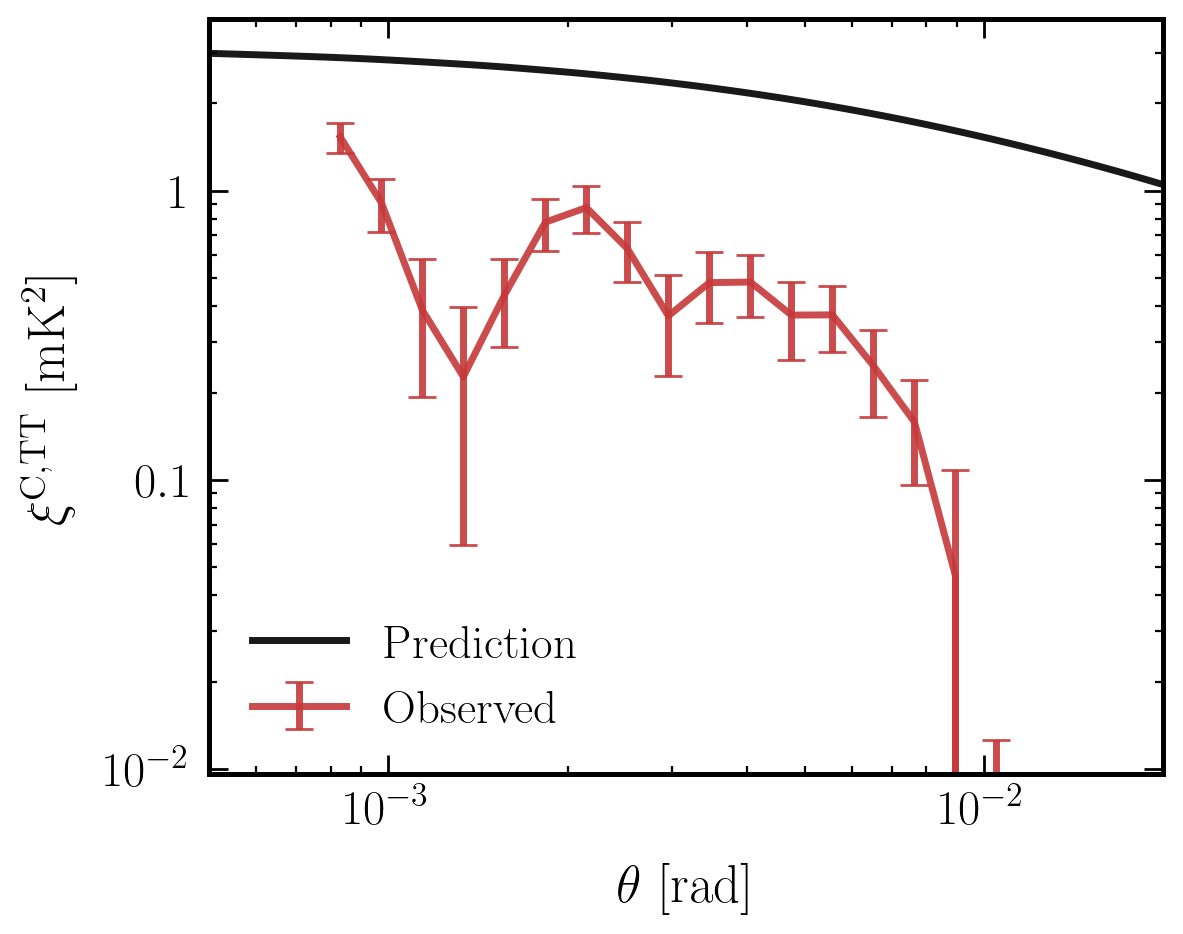

In [9]:
new_prefac = 2* np.pi * 410e6 * 6.58212e-16 # convert MHz to eV
analytic_theta = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/analytic_data/analytic_theta_ary.npy")
new_analytic_mA = np.sort(np.concatenate([np.geomspace(1e-15, 1e-14, 10), np.geomspace(5e-15, 1e-13, 15)[::2]]))
analytic_w = np.load(f"/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/analytic_data/analytic_w_mA{new_analytic_mA[12]:.3e}_no_mono.npy")
rnom, obs_xi = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/limits/21cmfast_roman_pyilc_limits17_mA_1.292e-15_obs_auto_xi.npy")
obs_xi_cov = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/limits/21cmfast_roman_pyilc_limits17_mA_1.292e-15_obs_auto_cov.npy")

plt.loglog(analytic_theta, (2.73e3)**2 * (2e-6)**4 * analytic_w/new_prefac**2, color="k", label="Prediction")
plt.errorbar(rnom, obs_xi/new_prefac**2, yerr=np.sqrt(np.diag(obs_xi_cov))/new_prefac**2, color=cols_default[0], label="Observed")
# plt.text(0.8e-3, 0.05, r"$m_{A'}=1.2\times 10^{14}$ eV, $\epsilon= 2\times 10^{-6}$")
plt.xlabel(r"$\theta$ [rad]")
plt.ylabel(r"$\xi^{\rm C, TT}$ [mK$^2$]")
plt.legend()
plt.xlim(5e-4, 2e-2)
# plt.ylim(1e-2, 3)